**Name: Bilal Wali**<br>
Roll no. **25MAM007**<br>
M.Sc AI&ML

**LSTM Model for for time series prediction** <br>
Source of dataset:  *NIFTY-50 Stock Market Data (2000 -
2021),*  https://www.kaggle.com/datasets/rohanrao/nifty50-stock-market-data/data

In [2]:
#Settting up Library:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
#The reading and also sorting of data:
df = pd.read_csv("BHARTIARTL.csv")

df["Datetime"] = pd.to_datetime(df["Date"])
df = df.sort_values("Datetime").reset_index(drop=True)

feature_names = ['Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 
                 'Turnover', 'Trades', 'Deliverable Volume', '%Deliverble']
numeric_df = df[feature_names].copy()

Features used: ['Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume', '%Deliverble']


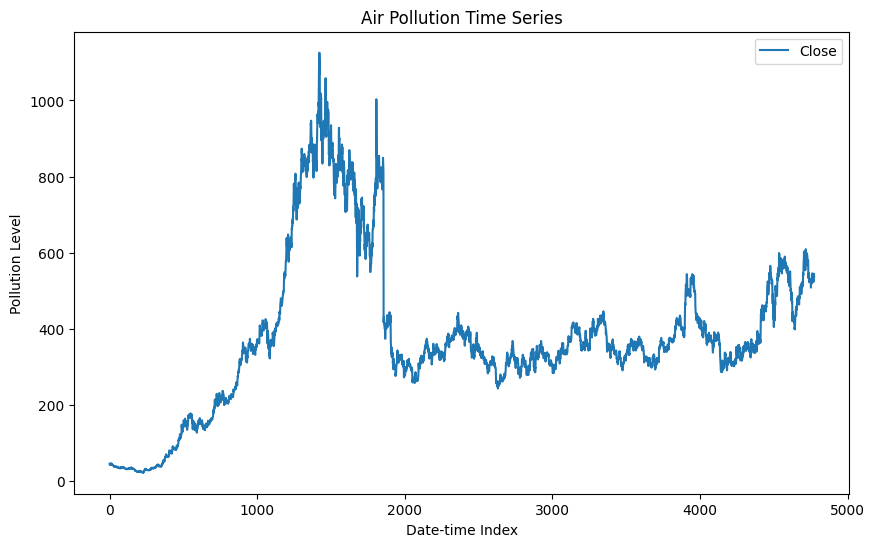

In [19]:
#cleaning :
numeric_df = numeric_df.replace(-200, np.nan)
numeric_df = numeric_df.interpolate(method="linear", limit_direction="both")
numeric_df = numeric_df.ffill().bfill()

#convert df to numpy:
feature_names = numeric_df.columns.tolist()
# Extract feature names from df for plots
num_features = numeric_df.shape[1] 
print("Features used:", feature_names)

#visualize the time series:
plt.figure(figsize=(10, 6))
plt.plot(numeric_df.index, numeric_df[feature_names[4]], label=feature_names[4])
plt.title('Air Pollution Time Series') # Title kept from PDF material
plt.xlabel('Date-time Index')
plt.ylabel('Pollution Level')
plt.legend()
plt.show()

In [23]:
#convert df to numpy
data = numeric_df.values.astype(np.float32)
print("Data shape:", data.shape)

Data shape: (4774, 11)


In [24]:
data

array([[5.1900002e+01, 5.1900002e+01, 4.3500000e+01, ..., 4.7549000e+04,
        6.5037750e+06, 6.2650001e-01],
       [4.5150002e+01, 4.5150002e+01, 4.1299999e+01, ..., 4.7549000e+04,
        1.7411840e+06, 4.9010000e-01],
       [4.0599998e+01, 4.2799999e+01, 4.0250000e+01, ..., 4.7549000e+04,
        1.1135765e+06, 4.2664999e-01],
       ...,
       [5.3595001e+02, 5.4800000e+02, 5.3559998e+02, ..., 1.2560000e+05,
        4.3442430e+06, 3.6289999e-01],
       [5.4970001e+02, 5.5000000e+02, 5.3909998e+02, ..., 9.8579000e+04,
        3.1383840e+06, 3.6140001e-01],
       [5.3350000e+02, 5.4700000e+02, 5.3350000e+02, ..., 1.0658000e+05,
        3.0451080e+06, 3.7230000e-01]], shape=(4774, 11), dtype=float32)

In [7]:
# Traintestsplit doing:
INPUT_STEPS = 10    # last 10 days      
OUTPUT_STEPS = 5    # next 5 days    since:(like that e.g.2: 'input is last 10days and then have to predcit next 5 days")
TRAIN_RATIO = 0.8
BATCH_SIZE = 4

# We Spliting data 80:20
split_idx = int(len(data) * TRAIN_RATIO)
train_data1 = data[:split_idx]
test_data = data[split_idx:]

val_split_idx = int(len(train_data1) * 0.8)
train_data = train_data1[:val_split_idx]
val_data = train_data1[val_split_idx:]

# Column-wise normalization
scaler = StandardScaler()
train_data_norm = scaler.fit_transform(train_data)
val_data_norm = scaler.transform(val_data)
test_data_norm = scaler.transform(test_data)

In [25]:
#now we preparing train/Test data with chunking:
def create_sequences(data_array, input_steps=10, output_steps=5, overlap=0):
    X, y = [], []
    total_len = len(data_array)
    # stride = input_steps - overlap
    stride = 1 # Using 1 for continuous sliding window
    for i in range(0, total_len - input_steps - output_steps + 1, stride):
        X.append(data_array[i : i + input_steps])
        y.append(data_array[i + input_steps : i + input_steps + output_steps])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = create_sequences(train_data_norm, INPUT_STEPS, OUTPUT_STEPS)
X_val, y_val = create_sequences(val_data_norm, INPUT_STEPS, OUTPUT_STEPS)
X_test, y_test = create_sequences(test_data_norm, INPUT_STEPS, OUTPUT_STEPS)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)

X_train: (3041, 10, 11) y_train: (3041, 5, 11)
X_test: (941, 10, 11) y_test: (941, 5, 11)
X_val: (750, 10, 11) y_val: (750, 5, 11)


In [27]:
#creating a custom dataset
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): 
        return len(self.X)
    def __getitem__(self, idx): 
        return self.X[idx], self.y[idx]

train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TimeSeriesDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TimeSeriesDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

In [10]:
#Define Model:
class LSTMForecaster(nn.Module):
    def __init__(self):
        super().__init__()
        #we using 11 features, 10 hidden units
        self.lstm = nn.LSTM(11, 10, batch_first=True)
        #and we output mapping to 5 days * 11 features
        self.fc = nn.Linear(10, 5 * 11)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.view(-1, 5, 11)

model = LSTMForecaster().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10)

In [28]:
#Instantiating model with a scheduler
model = LSTMForecaster().to(device)
lr = 0.0001
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10)

In [11]:
#Method for Training 1 epoch
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward(); optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
    return running_loss / len(loader.dataset)

#and Method for evaluation:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            running_loss += loss.item() * X_batch.size(0)
            all_preds.append(preds.cpu())
            all_targets.append(y_batch.cpu())
    return running_loss / len(loader.dataset), torch.cat(all_preds, 0).numpy(), torch.cat(all_targets, 0).numpy()

In [38]:
#one simple training:
print("Starting Simple Training (10 Epochs)...")
EPOCHS_SIMPLE = 10
for epoch in range(EPOCHS_SIMPLE):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, _, _ = evaluate(model, val_loader, criterion, device)
    print(f"Epoch [{epoch+1}/{EPOCHS_SIMPLE}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

#traiinng with early stopping:
print("\nStarting Training with Early Stopping...")
EPOCHS= 100
PATIENCE = 5
best_val_loss = float('inf')
no_improve = 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, _, _ = evaluate(model, val_loader, criterion, device)
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print("Early stopping triggered at epoch {}".format(epoch+1))
            break

Starting Simple Training (10 Epochs)...
Epoch [1/10] | Train Loss: 0.285878 | Val Loss: 0.559447
Epoch [2/10] | Train Loss: 0.285704 | Val Loss: 0.559567
Epoch [3/10] | Train Loss: 0.285554 | Val Loss: 0.558465
Epoch [4/10] | Train Loss: 0.285317 | Val Loss: 0.558570
Epoch [5/10] | Train Loss: 0.285242 | Val Loss: 0.559787
Epoch [6/10] | Train Loss: 0.285106 | Val Loss: 0.559816
Epoch [7/10] | Train Loss: 0.284995 | Val Loss: 0.559654
Epoch [8/10] | Train Loss: 0.284826 | Val Loss: 0.559258
Epoch [9/10] | Train Loss: 0.284688 | Val Loss: 0.559745
Epoch [10/10] | Train Loss: 0.284482 | Val Loss: 0.558324

Starting Training with Early Stopping...
Epoch [1/100] | Train Loss: 0.284358 | Val Loss: 0.558542
Epoch [2/100] | Train Loss: 0.284193 | Val Loss: 0.558536
Epoch [3/100] | Train Loss: 0.284082 | Val Loss: 0.559529
Epoch [4/100] | Train Loss: 0.283927 | Val Loss: 0.559063
Epoch [5/100] | Train Loss: 0.283705 | Val Loss: 0.558249
Epoch [6/100] | Train Loss: 0.283658 | Val Loss: 0.558399

In [39]:
#test dataset evalutaion:
model.load_state_dict(torch.load("best_model.pt"))

test_loss, predictions, targets = evaluate(model, test_loader, criterion, device)

print("Final Test Loss:", test_loss)
print("\npredictions.shape, targets.shape:", predictions.shape, targets.shape)



Final Test Loss: 7.319615893137189

predictions.shape, targets.shape: (941, 5, 11) (941, 5, 11)


In [40]:
# also now, MSE, RMSE, MAE calculations:
y_true_flat = targets.reshape(-1, 11)
y_pred_flat = predictions.reshape(-1, 11)

mse = mean_squared_error(y_true_flat, y_pred_flat)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_flat, y_pred_flat)

print("MSE: {:.6f}".format(mse))
print("RMSE: {:.6f}".format(rmse))
print("MAE: {:.6f}".format(mae))


MSE: 7.319618
RMSE: 2.705479
MAE: 0.958889


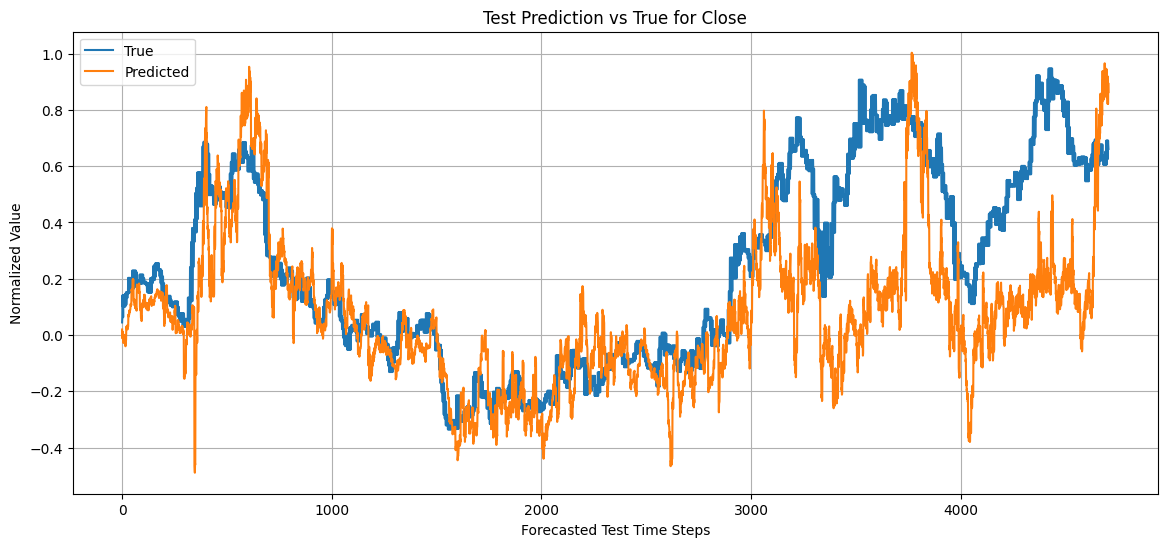

In [41]:
# Plot predictions v/s True labels on test dataset:
PLOT_FEATURE = "Close"
feature_idx = feature_names.index(PLOT_FEATURE)

pred_feature = predictions[:, :, feature_idx].reshape(-1)
true_feature = targets[:, :, feature_idx].reshape(-1)

plt.figure(figsize=(14, 6))
plt.plot(true_feature, label="True")
plt.plot(pred_feature, label="Predicted")
plt.title(f"Test Prediction vs True for {PLOT_FEATURE}")
plt.xlabel("Forecasted Test Time Steps")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(True)
plt.show()